# Лабораторная работа E2 — Спектр: из каких частот состоит сигнал

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/biomenace/digital-signal-processing/blob/main/notebooks/e2.ipynb)

Ноутбук-спутник к интерактивной работе: **[открыть саму лабораторную](https://biomenace.github.io/digital-signal-processing/labs/e2.html)**.

**Что разбираем.** Любой сигнал можно представить как сумму синусов разных
частот. Дискретное преобразование Фурье (ДПФ) находит, каких именно частот и
сколько в нём есть. Результат — **спектр**: по горизонтали частота, по
вертикали её вклад в сигнал.

Три факта, которые проверим в коде:

1. один чистый синус → один пик ровно на его частоте;
2. несколько тонов → несколько пиков, каждый на своём месте;
3. шум → «трава» по всей оси частот, на её фоне пики могут потеряться.

Спектр виден только до частоты Найквиста $F_д/2$ — выше него ничего
измерить нельзя (это лаба E1).

In [1]:
# ЯЧЕЙКА 1 · Установка и импорты.
# Запусти один раз в начале работы и больше сюда не возвращайся.
# В Google Colab почти всё уже стоит, поэтому обычно ничего не скачивается.

import importlib.util
import subprocess
import sys


def ensure(packages):
    """Ставит только те пакеты, которых нет. packages: [(модуль, имя-для-pip)]."""
    missing = [pip for mod, pip in packages if not importlib.util.find_spec(mod)]
    if missing:
        print("Ставлю:", ", ".join(missing))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing],
                       check=True)
    print("Готово. Python", sys.version.split()[0])


ensure([("numpy", "numpy"), ("scipy", "scipy"), ("matplotlib", "matplotlib")])

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline
matplotlib.rcParams.update({
    "figure.figsize": (11, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.linewidth": 0.4,
    "axes.titlesize": 12,
    "font.size": 11,
})

Готово. Python 3.10.12


## Ячейка 2 · Вспомогательные функции

Сборка сигнала из тонов, расчёт амплитудного спектра, поиск пиков и рисование.
Запусти один раз и дальше просто вызывай.

In [2]:
def make_signal(tones, fs, n, noise=0.0, seed=0):
    """Сумма синусов (частота, амплитуда) плюс гауссов шум. Возвращает (t, s)."""
    rng = np.random.default_rng(seed)
    t = np.arange(n) / fs
    s = np.zeros(n)
    for freq, amp in tones:
        s += amp * np.sin(2 * np.pi * freq * t)
    s += noise * rng.standard_normal(n)
    return t, s


def spectrum(s, fs):
    """Амплитудный спектр: частоты и модуль, нормированный так, что чистый
    синус амплитуды A даёт пик высотой примерно A."""
    n = len(s)
    mag = 2 * np.abs(np.fft.rfft(s)) / n
    freqs = np.fft.rfftfreq(n, d=1.0 / fs)
    return freqs, mag


def find_peaks(freqs, mag, rel_threshold=0.25):
    """Локальные максимумы выше доли rel_threshold от самого высокого пика."""
    limit = rel_threshold * mag.max()
    return [(freqs[k], mag[k]) for k in range(1, len(mag) - 1)
            if mag[k] > mag[k - 1] and mag[k] >= mag[k + 1] and mag[k] > limit]


def report_peaks(tones, freqs, mag, fs):
    """Печатает, что задавали и что нашлось в спектре."""
    print("Задано:", ", ".join("%g Гц (A=%.2f)" % (f, a) for f, a in tones))
    peaks = find_peaks(freqs, mag)
    print("Найдено пиков: %d" % len(peaks))
    for freq, amp in peaks:
        print("   пик на %6.1f Гц, высота %.2f" % (freq, amp))
    print("Спектр виден до Найквиста F_д/2 = %g Гц." % (fs / 2))
    return peaks


def plot_signal_and_spectrum(t, s, freqs, mag, title=""):
    """Две панели: сигнал во времени и его спектр."""
    fig, ax = plt.subplots(2, 1, figsize=(11, 6))
    ax[0].plot(t, s, color="steelblue", lw=1.1)
    ax[0].set(xlabel="$t$, с", ylabel="$s(t)$", title="Сигнал во времени" +
              (" — " + title if title else ""))
    ax[1].plot(freqs, mag, color="steelblue", lw=1.4)
    ax[1].set(xlabel="$f$, Гц", ylabel="$|S(f)|$", title="Спектр")
    fig.tight_layout()
    plt.show()

## Ячейка 3 · Один чистый синус

Самый простой случай: в сигнале ровно одна частота — в спектре ровно один пик.

Задано: 15 Гц (A=1.00)
Найдено пиков: 1
   пик на   14.8 Гц, высота 0.93
Спектр виден до Найквиста F_д/2 = 100 Гц.


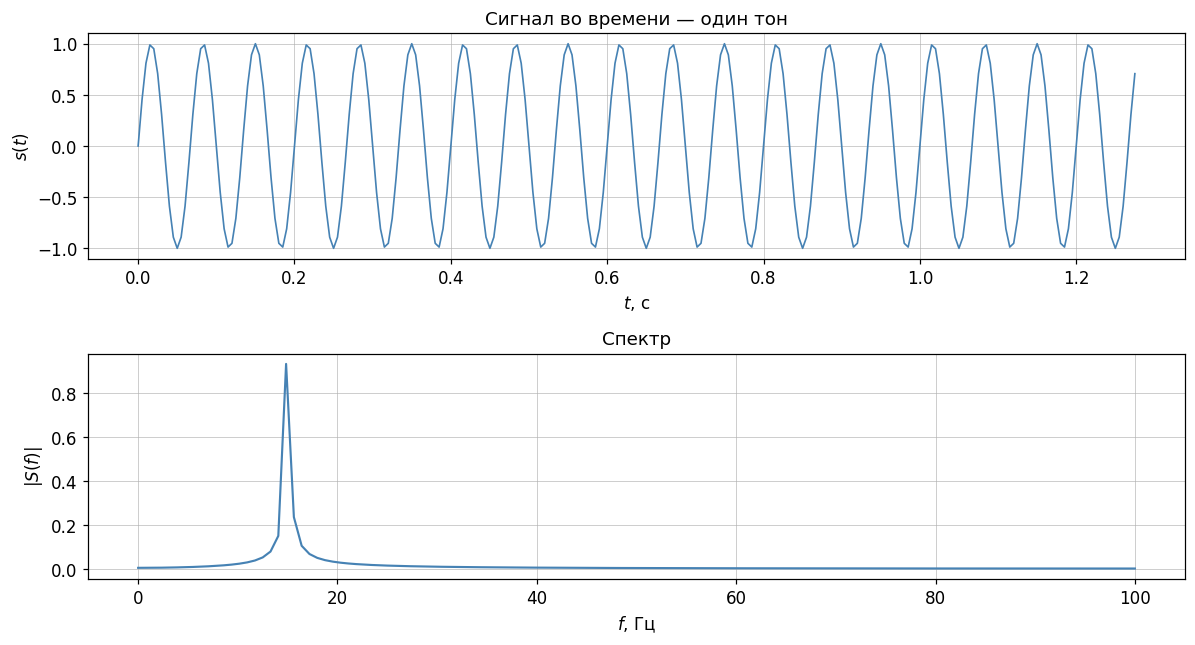

In [3]:
FS = 200.0    # частота дискретизации, Гц
N = 256       # длина окна, отсчётов

tones = [(15.0, 1.0)]
t, s = make_signal(tones, FS, N)
freqs, mag = spectrum(s, FS)

report_peaks(tones, freqs, mag, FS)
plot_signal_and_spectrum(t, s, freqs, mag, "один тон")

## Ячейка 4 · Несколько тонов

Добавим второй и третий тон с разными амплитудами. Высота каждого пика
соответствует амплитуде своего тона — спектр не просто показывает «что есть»,
он показывает «сколько».

Задано: 15 Гц (A=1.00), 40 Гц (A=0.60), 70 Гц (A=0.30)
Найдено пиков: 3
   пик на   14.8 Гц, высота 0.93
   пик на   39.8 Гц, высота 0.55
   пик на   70.3 Гц, высота 0.23
Спектр виден до Найквиста F_д/2 = 100 Гц.


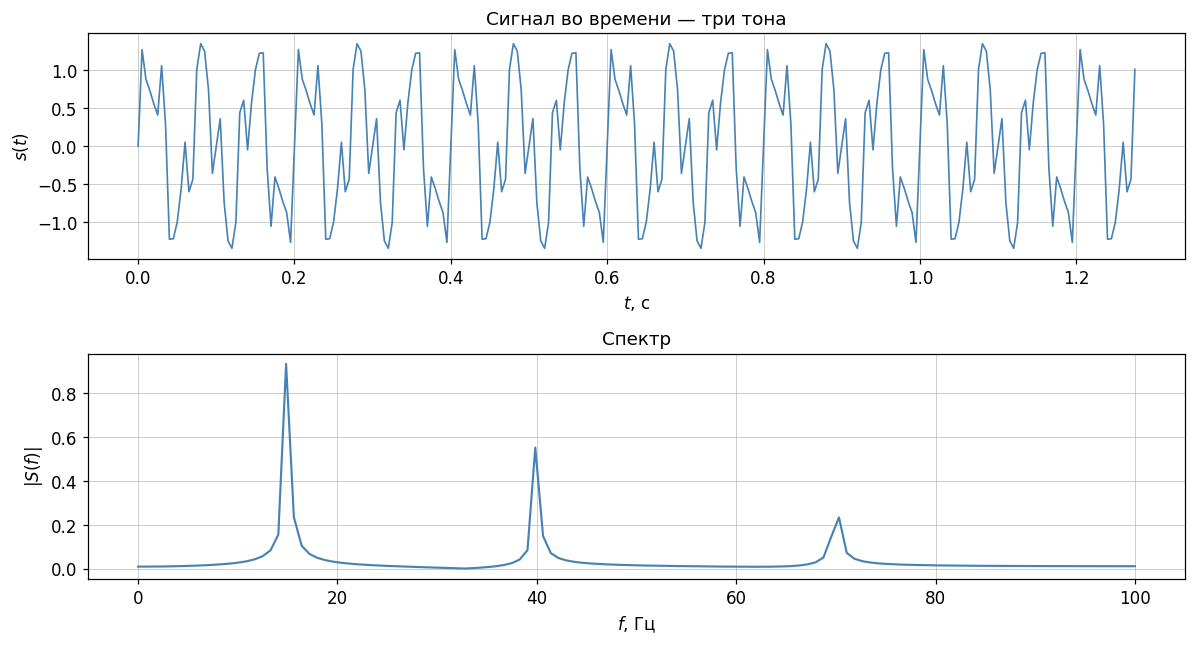

In [4]:
TONES = [(15.0, 1.0), (40.0, 0.6), (70.0, 0.3)]

t, s = make_signal(TONES, FS, N)
freqs, mag = spectrum(s, FS)

report_peaks(TONES, freqs, mag, FS)
plot_signal_and_spectrum(t, s, freqs, mag, "три тона")

Во временной области три тона уже неразличимы на глаз — видно только сложную
волну. В спектре они разделены сразу.

## Ячейка 5 · Что делает шум

Шум не имеет выделенной частоты, поэтому размазывается по всей оси. Слабые
пики он топит первыми.

Задано: 15 Гц (A=1.00), 40 Гц (A=0.60), 70 Гц (A=0.30)
Найдено пиков: 7
   пик на    4.7 Гц, высота 0.22
   пик на   14.8 Гц, высота 0.85
   пик на   25.8 Гц, высота 0.23
   пик на   39.8 Гц, высота 0.55
   пик на   55.5 Гц, высота 0.23
   пик на   70.3 Гц, высота 0.23
   пик на   79.7 Гц, высота 0.25
Спектр виден до Найквиста F_д/2 = 100 Гц.


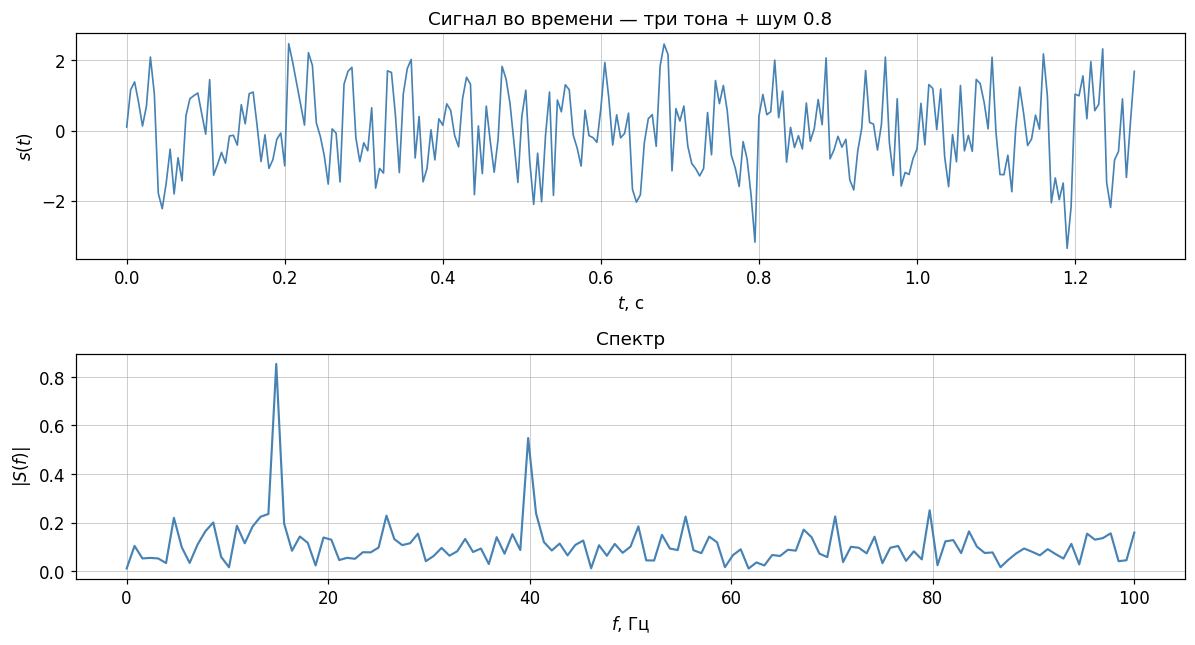

In [5]:
NOISE = 0.8   # СКО шума; попробуй 0.2, 0.8, 2.0

t, s = make_signal(TONES, FS, N, noise=NOISE)
freqs, mag = spectrum(s, FS)

report_peaks(TONES, freqs, mag, FS)
plot_signal_and_spectrum(t, s, freqs, mag, "три тона + шум %.1f" % NOISE)

## Ячейка 6 · Разрешение по частоте зависит от длины окна

Два близких тона сливаются в один пик, если окно слишком короткое.
Шаг сетки частот равен $F_д/N$, и различить тона можно, только если
расстояние между ними больше этого шага.

N =  64 отсчётов  →  шаг сетки 3.12 Гц, окно 0.32 с, пиков найдено: 1
N = 128 отсчётов  →  шаг сетки 1.56 Гц, окно 0.64 с, пиков найдено: 2
N = 512 отсчётов  →  шаг сетки 0.39 Гц, окно 2.56 с, пиков найдено: 2


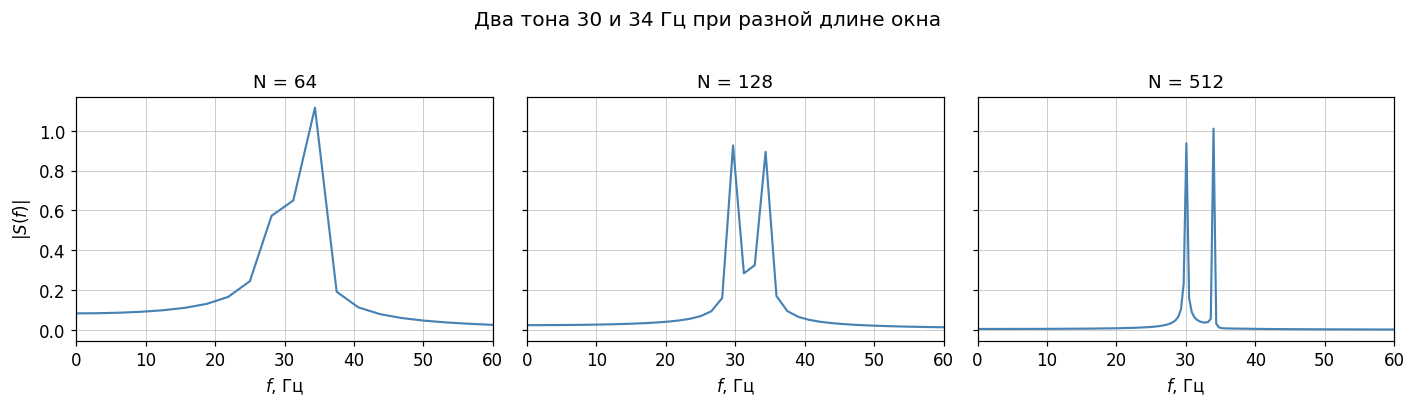

In [6]:
CLOSE_TONES = [(30.0, 1.0), (34.0, 1.0)]   # разница всего 4 Гц

for n_win in (64, 128, 512):
    t, s = make_signal(CLOSE_TONES, FS, n_win)
    freqs, mag = spectrum(s, FS)
    peaks = find_peaks(freqs, mag, rel_threshold=0.5)
    print("N = %3d отсчётов  →  шаг сетки %.2f Гц, окно %.2f с, пиков найдено: %d"
          % (n_win, FS / n_win, n_win / FS, len(peaks)))

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for axis, n_win in zip(ax, (64, 128, 512)):
    t, s = make_signal(CLOSE_TONES, FS, n_win)
    freqs, mag = spectrum(s, FS)
    axis.plot(freqs, mag, color="steelblue", lw=1.4)
    axis.set(xlim=(0, 60), xlabel="$f$, Гц", title="N = %d" % n_win)
ax[0].set(ylabel="$|S(f)|$")
fig.suptitle("Два тона 30 и 34 Гц при разной длине окна", y=1.02)
fig.tight_layout()
plt.show()

Чем длиннее окно, тем тоньше различие по частоте, которое можно поймать.
Обратная сторона — длинное окно хуже ловит быстрые изменения во времени.
Этот компромисс разбирается в лабе E4.

## Задания

1. Поставь свой набор тонов из таблицы вариантов и запиши частоты и высоты
   найденных пиков.
2. Подними шум до уровня, при котором самый слабый тон перестаёт находиться.
   Запиши это СКО.
3. Для двух близких тонов из своего варианта найди минимальное $N$, при
   котором они всё ещё различимы как два пика.